# Bowley's Skewness

Q1: 13.35 | Median (Q2): 17.80 | Q3: 24.13
Bowley Skewness: -13.269


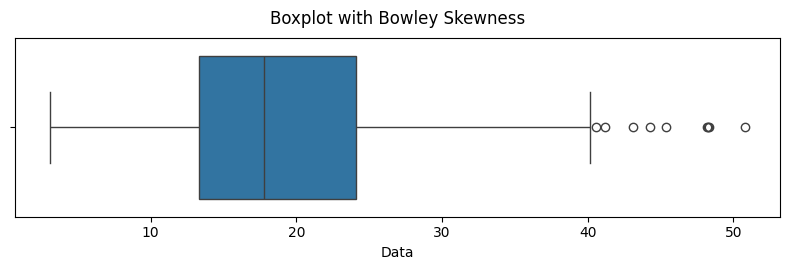

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
tips = sns.load_dataset('tips')
data = tips['total_bill']

q1, q2, q3 = np.percentile(data, [25, 50, 75])
bowley_skew = (q1 + q3 - 2 * q2) / q3 - q1

print(f"Q1: {q1:.2f} | Median (Q2): {q2:.2f} | Q3: {q3:.2f}")
print(f"Bowley Skewness: {bowley_skew:.3f}")

plt.figure(figsize=(8, 2.8))
ax = sns.boxplot(x=data)
ax.set_title("Boxplot with Bowley Skewness", pad=10)
ax.set_xlabel("Data")
plt.tight_layout()
plt.show()

# Skewness and Kurtosis

Skewness: 1.13
Kurtosis: 1.17


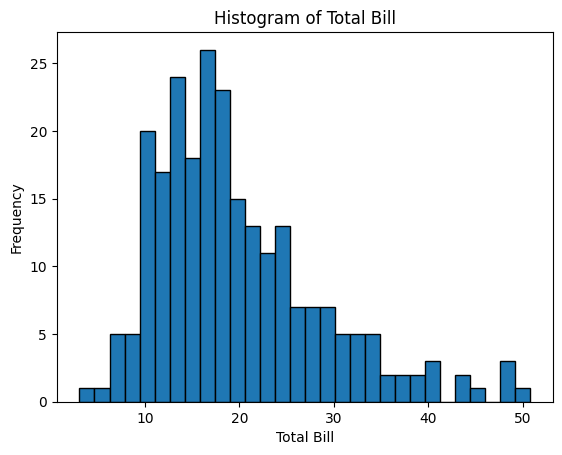

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew, kurtosis
tips = sns.load_dataset('tips')
data = tips['total_bill']

print(f'Skewness: {skew(data):.2f}')
print(f'Kurtosis: {kurtosis(data):.2f}')

plt.hist(data, bins=30, edgecolor="black")
plt.xlabel('Total Bill')
plt.ylabel('Frequency')
plt.title('Histogram of Total Bill')
plt.show()

# Performance Evaluation

In [34]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

diabetes = load_diabetes()

X = diabetes.data
y = diabetes.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
mase = mae / (sum(abs(y_test[i + 1] - y_test[i]) for i in range(len(y_test) - 1)) / (len(y_test) - 1))

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Square Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}")
print(f"Mean Absolute Scaled Error (MASE): {mase:.2f}")


Mean Absolute Error (MAE): 42.79
Root Mean Square Error (RMSE): 2900.19
Mean Absolute Percentage Error (MAPE): 0.37
Mean Absolute Scaled Error (MASE): 0.53


# Outlier Detection

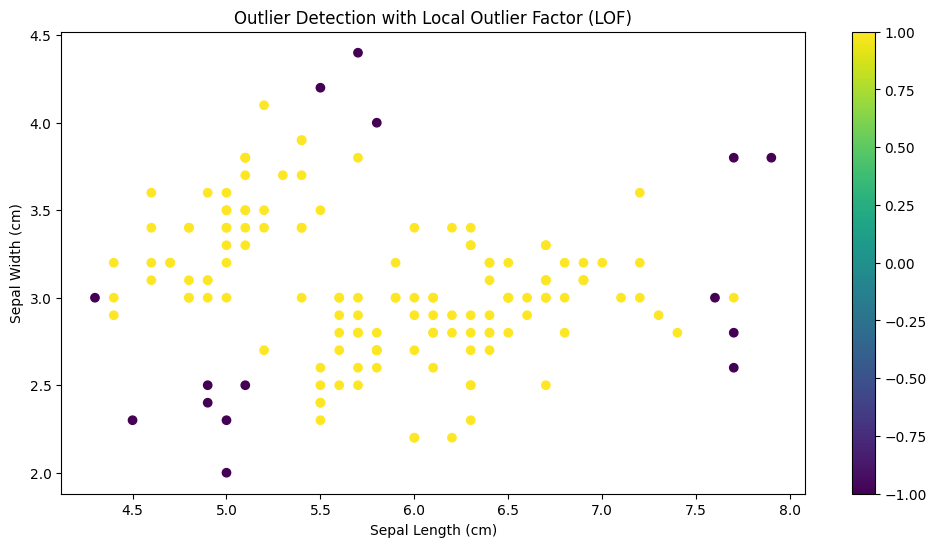

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.neighbors import LocalOutlierFactor

iris = load_iris()
X = iris.data
y = iris.target

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
y_pred = lof.fit_predict(X)

plt.figure(figsize=(12, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis')
plt.colorbar()
plt.title('Outlier Detection with Local Outlier Factor (LOF)')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.show()


# Normal Distribution

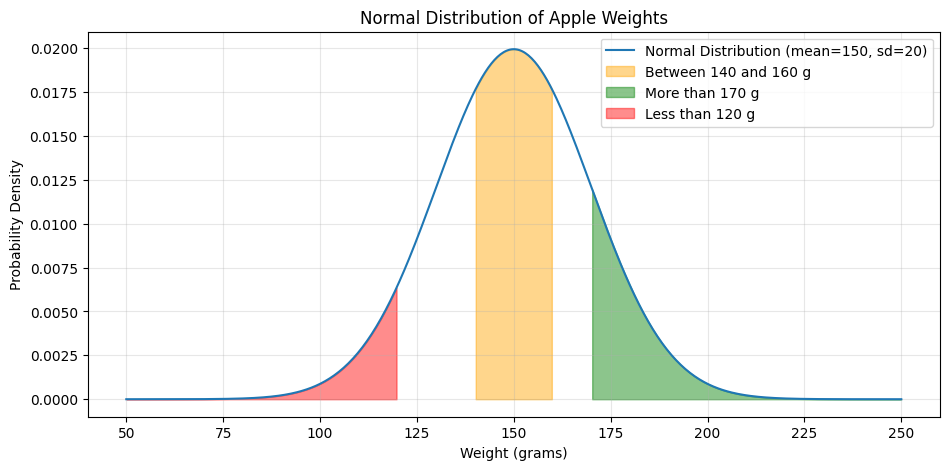

P(140 <= X <= 160): 0.3829
P(X > 170): 0.1587
P(X < 120): 0.0668


In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

mean, std = 150, 20
x = np.linspace(50, 250, 500)
y = norm.pdf(x, mean, std)

plt.figure(figsize=(11, 5))
plt.plot(x, y, label=f"Normal Distribution (mean={mean}, sd={std})")

regions = [
    ((x >= 140) & (x <= 160), "orange", "Between 140 and 160 g"),
    (x > 170, "green", "More than 170 g"),
    (x < 120, "red", "Less than 120 g"),
]
for mask, color, label in regions:
    plt.fill_between(x, 0, y, where=mask, color=color, alpha=0.45, label=label)

plt.xlabel("Weight (grams)")
plt.ylabel("Probability Density")
plt.title("Normal Distribution of Apple Weights")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

p_140_160 = norm.cdf(160, mean, std) - norm.cdf(140, mean, std)
p_gt_170 = 1 - norm.cdf(170, mean, std)
p_lt_120 = norm.cdf(120, mean, std)

print(f"P(140 <= X <= 160): {p_140_160:.4f}")
print(f"P(X > 170): {p_gt_170:.4f}")
print(f"P(X < 120): {p_lt_120:.4f}")